In [1]:
import numpy as np
import pandas as pd
from matplotlib import pyplot as plt
import seaborn as sbs
import math as math
import os
from os import listdir
pd.options.mode.use_inf_as_na = True
import tkinter
from tkinter import filedialog

In [2]:
tkinter.Tk().withdraw()
filepath = filedialog.askdirectory()

In [4]:
# df_files = {}
# i = 0

# for root, dirs, files in os.walk(filepath):
#     if ".csv" in str(files) and "Trial" in str(files):
#         for f in listdir(path=root):
#             if ".csv" in str(f):
#                     a = pd.read_csv(root + '\\' + f)
#                     y = a.xs('Y (cm)', axis=1)
#                     x = a.xs('X (cm)', axis=1)
#                     speed = a.xs('SPEED#wcentroid (cm/s)', axis=1)
#                     vy = a.xs('VY (cm/s)', axis=1)
#                     frame = a.frame
#                     df_files[str(i)] = pd.DataFrame({"Y" : y, "X" : x, "Speed" : speed, "VY" : vy, "Frame" : frame, "Trial" : str(f), "Condition" : str(root.rsplit('\\')[-2])})
#                     i = i+1

# complete_df = pd.concat(df_files)

In [3]:
df_files = {}
i = 0

for root, dirs, files in os.walk(filepath):
    if ".csv" in str(files) and "Trial" in str(files):
        for f in listdir(path=root):
            if ".csv" in str(f):
                    a = pd.read_csv(root + '\\' + f)
                    y = a.xs('Y (cm)', axis=1)
                    x = a.xs('X (cm)', axis=1)
                    speed = a.xs('SPEED#wcentroid (cm/s)', axis=1)
                    vy = a.xs('VY (cm/s)', axis=1)
                    frame = a.frame
                    df_files[str(i)] = pd.DataFrame({"Y" : y, "X" : x, "Speed" : speed, "VY" : vy, "Frame" : frame, "Trial" : str(root.rsplit('\\')[-1]), "Condition" : str(root.rsplit('\\')[-2])})
                    i = i+1

complete_df = pd.concat(df_files)

In [4]:
#Cleaning the data: ridding it of infs
clean_complete_df = complete_df.dropna()

clean_complete_df.head()


Y       X  Speed     VY  Frame    Trial        Condition
0 0  16.427  13.335  0.000  0.000    0.0  Trial 1  Orco - 10-3 cVA
  1  16.667  13.137  0.441  2.396    1.0  Trial 1  Orco - 10-3 cVA
  2  16.450  13.318  0.239 -2.166    2.0  Trial 1  Orco - 10-3 cVA
  3  16.440  13.320  0.086 -0.101    3.0  Trial 1  Orco - 10-3 cVA
  4  16.447  13.325  0.350  0.074    4.0  Trial 1  Orco - 10-3 cVA

In [5]:
conditions = clean_complete_df['Condition'].unique().tolist()

trials_dict = {}

for cond in conditions:
    key = f'{cond}'
    sub_df = clean_complete_df[clean_complete_df['Condition'] == cond] 
    value = sub_df['Trial'].unique().tolist()
    trials_dict[key] = value



In [6]:
#Inserting a distance column
clean_complete_df.insert(4, 'Distance', 0)

In [7]:
for cond in conditions:
    for trial in trials_dict[f'{cond}']:
        sub_df = clean_complete_df[(clean_complete_df['Condition'] == cond) & (clean_complete_df['Trial'] == trial)]
        #Calculating centroid position

        x_centroid_list = []
        y_centroid_list = []

        frame_list = sub_df['Frame'].values.tolist()
        for f in range(0, int(max(frame_list))):
            cropped_pos = sub_df.loc[sub_df['Frame'] == f]
            av_x = cropped_pos['X'].mean()
            x_centroid_list.append(av_x)
            av_y = cropped_pos['Y'].mean()
            y_centroid_list.append(av_y)

        coordlist = list(zip(x_centroid_list, y_centroid_list))
        t = np.arange(np.size(x_centroid_list))

        x_1 = x_centroid_list[0]
        y_1 = y_centroid_list[0]

        for f in sub_df.index:
            x_2 = sub_df.X[f]
            y_2 = sub_df.Y[f]
            dist = math.sqrt((x_2-x_1)**2 + (y_2-y_1)**2)
            clean_complete_df.Distance[f] = dist



C:\Users\hpnhp\AppData\Local\Temp\ipykernel_19292\2614076390.py:27: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  clean_complete_df.Distance[f] = dist


In [8]:
distance_grouped = clean_complete_df.groupby(['Condition', 'Trial']).Speed.mean()

distance_grouped = distance_grouped.reset_index()

In [9]:
distance_grouped = distance_grouped.pivot(index='Trial', columns='Condition', values = 'Speed')

In [10]:
distance_grouped.head()

Condition,Orco - 10-3 cVA,Orco - Ethanol,Orco - Water,WT - 10-3 cVA,WT - Ethanol,WT - Water,ppk23 10-3 cVA in Ethanol
Trial,,,,,,,
Trial 1,0.517044,0.525937,0.447936,0.719357,0.718285,0.807596,0.850233
Trial 2,0.583059,0.479043,0.513356,0.598786,0.886986,0.885425,0.857105
Trial 3,0.457572,0.481779,0.480344,0.753132,0.692682,0.665071,0.765236
Trial 4,0.508266,0.515366,0.573933,0.878017,0.844677,0.977669,0.753109
Trial 5,0.577504,0.605870,0.514654,0.562057,0.711814,0.939713,0.658430


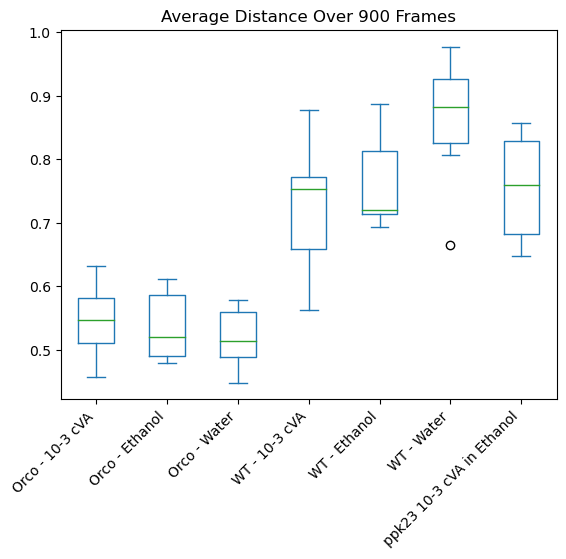

In [12]:
#for index in distance_grouped.index:
    #sbs.boxenplot(data = distance_grouped, x = distance_grouped[index], y = 'Condition')

ax = distance_grouped.plot(kind='box')
ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right')  # Rotate labels by 45 degrees
plt.title('Average Distance Over 900 Frames')


plt.show()

#sbs.boxenplot(x='Condition', y='Distance', data=distance_grouped, color='blue', width=0.4)
#plt.legend()
#plt.show()

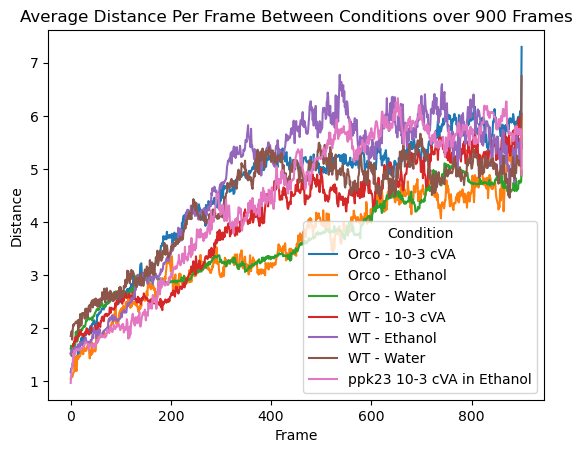

In [14]:
frame_dist_df = clean_complete_df.groupby(['Condition', 'Frame']).Distance.mean()

ax = sbs.lineplot(data = frame_dist_df, x = 'Frame' ,y = frame_dist_df, hue = 'Condition')
plt.title('Average Distance Per Frame Between Conditions over 900 Frames')

plt.show()

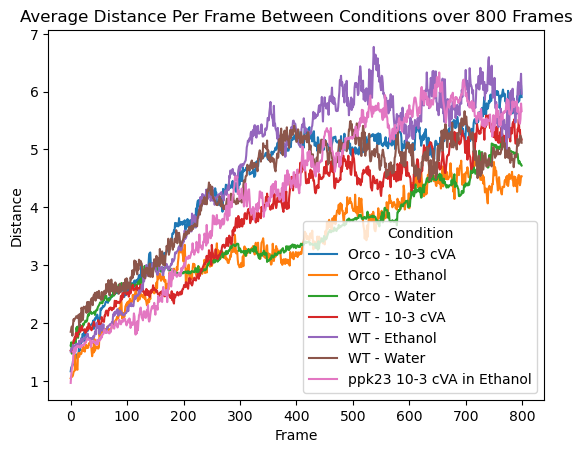

In [16]:
#To analyze cropped parts of the dataset

cropped_ccd = clean_complete_df[clean_complete_df['Frame']<800]

frame_dist_df = cropped_ccd.groupby(['Condition', 'Frame']).Distance.mean()

ax = sbs.lineplot(data = frame_dist_df, x = 'Frame' ,y = frame_dist_df, hue = 'Condition')
plt.title('Average Distance Per Frame Between Conditions over 800 Frames')

plt.show()

In [16]:
#frame_dist_df_WT = frame_dist_df[frame_dist_df['Condition'] == 'WT -Ethanol']

#frame_dist_df = frame_dist_df.reset_index()

In [30]:
frame_dist_df_WT =  cropped_ccd[
    (cropped_ccd['Condition'] == 'WT - Ethanol')
    | (cropped_ccd['Condition'] == 'WT - Water') 
    | (cropped_ccd['Condition'] == 'WT - 10-3 cVA')
    ]

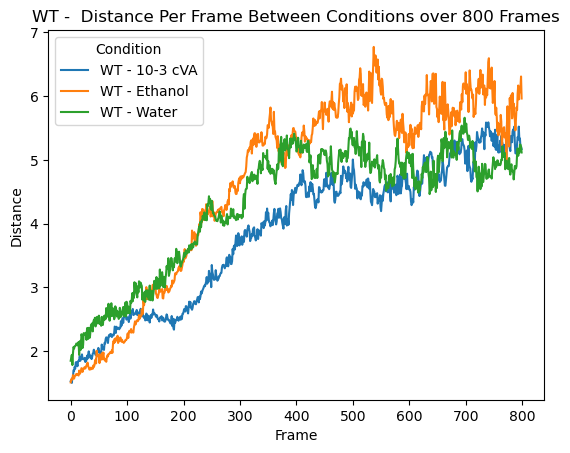

In [31]:
frame_dist_df_WT = frame_dist_df_WT.groupby(['Condition', 'Frame']).Distance.mean()

ax = sbs.lineplot(data = frame_dist_df_WT, x = 'Frame' ,y = frame_dist_df_WT, hue = 'Condition')
plt.title('WT -  Distance Per Frame Between Conditions over 800 Frames')

plt.show()

In [33]:
frame_dist_df_Orco = cropped_ccd[(cropped_ccd['Condition'] == 'Orco - Ethanol') 
| (cropped_ccd['Condition'] == 'Orco - Water') 
| (cropped_ccd['Condition'] == 'Orco - 10-3 cVA')
]

Text(0.5, 1.0, 'Orco -  Distance Per Frame Between Conditions over 800 Frames')

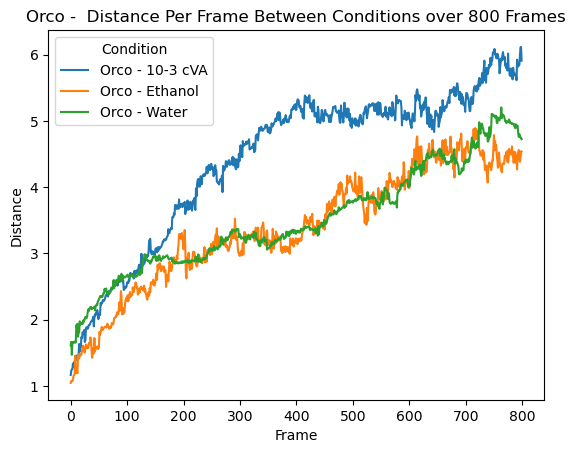

In [34]:
frame_dist_df_Orco = frame_dist_df_Orco.groupby(['Condition', 'Frame']).Distance.mean()

ax = sbs.lineplot(data = frame_dist_df_Orco, x = 'Frame' ,y = frame_dist_df_Orco, hue = 'Condition')
plt.title("Orco -  Distance Per Frame Between Conditions over 800 Frames")

In [21]:
# Retention index - bin data into >3cm and <3cm 

# for cond in conditions:
#     for trial in trials_dict[f'{cond}']:
#         sub_df = clean_complete_df[(clean_complete_df['Condition'] == cond) & (clean_complete_df['Trial'] == trial)]
#         list of retention indices per trial per condition - make it a series and then collate them all into a big dataframe
#         index by condition and frame letsgooo - generates means and standard deviation across x trials in yth frame
#         plot mean and std deviation of retention index as lineplot
#         for frame in frame_list:
#               frame_sub_df = sub_df[(sub_df['Frame'] == frame)]
#               sum_side = frame_sub_df['Distance'].sum()
#               total_side = sum_side = frame_sub_df['Distance'].count()
#               ret_index =          

In [22]:
def compare_to_constant(df, column_name, constant):
    # Create a new column based on the comparison
    df['Side'] = (df[column_name] < constant).astype(int)
    
    return df

In [31]:
retention_df = compare_to_constant(clean_complete_df, 'Distance', 3)

C:\Users\hpnhp\AppData\Local\Temp\ipykernel_6100\2237461871.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['Side'] = (df[column_name] < constant).astype(int)


In [47]:
def ret_index_calc(frame_sub_df):            
    sum_side = frame_sub_df['Side'].sum()
    total_side = frame_sub_df['Side'].count()
    if total_side > 0:
        ret_index = sum_side/total_side
    else:
        ret_index = 0
    return ret_index

In [140]:
retained_df = pd.DataFrame(
    {"Condition" : [],
     "Trial" : [],
     "Retention" : [],
     "Frame" : []    
     })

for cond in conditions:
    for trial in trials_dict[f'{cond}']:
        sub_df = retention_df[(retention_df['Condition'] == cond) & (retention_df['Trial'] == trial)]
        ret_list = []
        frame_list = sub_df["Frame"].unique().tolist()
        for frame in frame_list:
              frame_sub_df = sub_df[(sub_df['Frame'] == frame)]
              ret_frame = ret_index_calc(frame_sub_df)
              ret_list.append(ret_frame)
        temp_retention_df = pd.DataFrame(
             {    "Condition" : cond,
                  "Trial" : trial,
                  "Retention" : ret_list,
                  "Frame" : frame_list
             }
        )
        retained_df = pd.concat([retained_df, temp_retention_df])

In [134]:
# Grouped Analysis for Retention with Distance Values > 3

retained_grouped_df_mean = retained_df.groupby(['Condition', 'Trial']).Retention.mean()
retained_grouped_df_mean = retained_grouped_df_mean.reset_index()

#retained_grouped_df_mean = retained_grouped_df_mean.pivot(index = "Trial", columns= "Condition", values="Retention")

In [135]:
#retained_grouped_df_mean = retained_grouped_df_mean.reset_index()
retained_grouped_df_mean.head()

,Condition,Trial,Retention
0,Orco - 10-3 cVA,Trial 1,0.491221
1,Orco - 10-3 cVA,Trial 2,0.535454
2,Orco - 10-3 cVA,Trial 3,0.540496
3,Orco - 10-3 cVA,Trial 4,0.339205
4,Orco - 10-3 cVA,Trial 5,0.408517


In [136]:
retained_grouped_df_mean.drop(columns=["Trial"],inplace=True)

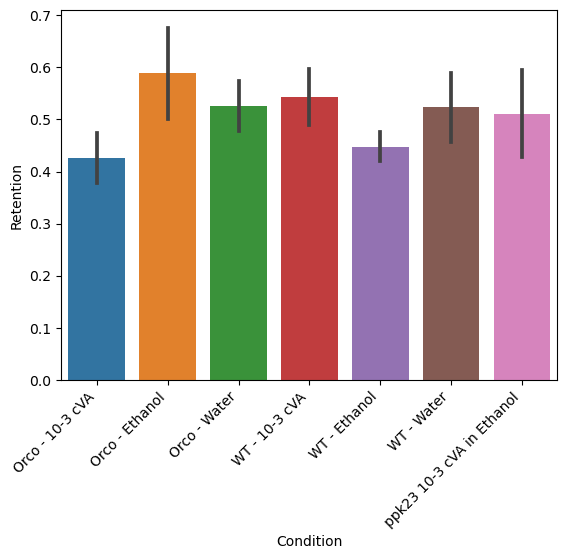

In [137]:
ax = sbs.barplot(data = retained_grouped_df_mean, x = "Condition", y = "Retention", errorbar="se")
ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right')  # Rotate labels by 45 degrees

plt.show()

In [145]:
retained_byframe = retained_df.groupby(["Condition", "Frame"]).Retention.mean()

In [146]:
retained_byframe = retained_byframe.reset_index()
retained_byframe.head()

,Condition,Frame,Retention
0,Orco - 10-3 cVA,0.0,0.988889
1,Orco - 10-3 cVA,1.0,0.988889
2,Orco - 10-3 cVA,2.0,0.988889
3,Orco - 10-3 cVA,3.0,0.988889
4,Orco - 10-3 cVA,4.0,0.966667


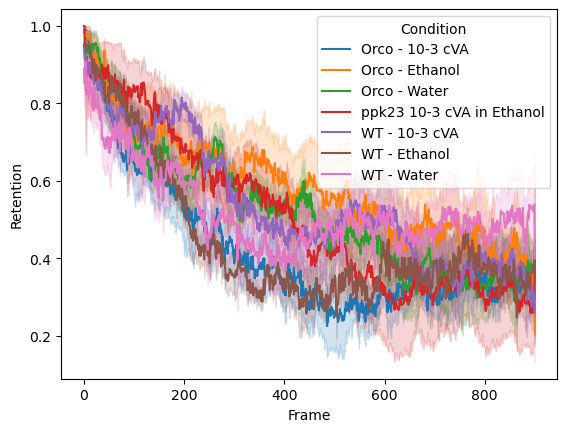

In [152]:
ax = sbs.lineplot(data = retained_df, x = "Frame", y = "Retention", hue="Condition", errorbar="se")
plt.show()

In [160]:
retained_df_orco = retained_df[(retained_df["Condition"] == "Orco - Water") 
                                    | (retained_df["Condition"] == "Orco - Ethanol") 
                                    | (retained_df["Condition"] == "Orco - 10-3 cVA")
                                    ]



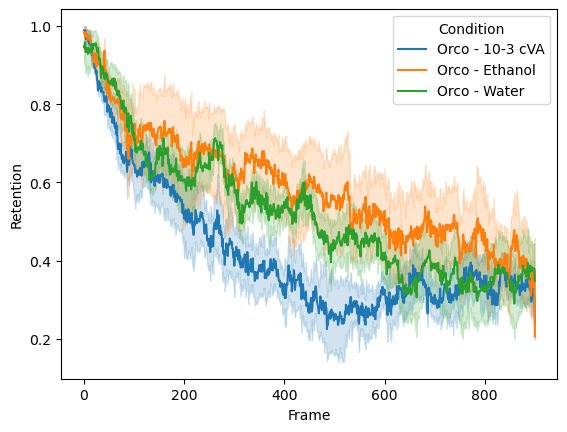

In [161]:
ax = sbs.lineplot(data = retained_df_orco, x = "Frame", y = "Retention", hue="Condition", errorbar="se")
plt.show()

In [162]:
retained_df_WT = retained_df[(retained_df["Condition"] == "WT - Water") 
                                    | (retained_df["Condition"] == "WT - Ethanol") 
                                    | (retained_df["Condition"] == "WT - 10-3 cVA")
                                    ]



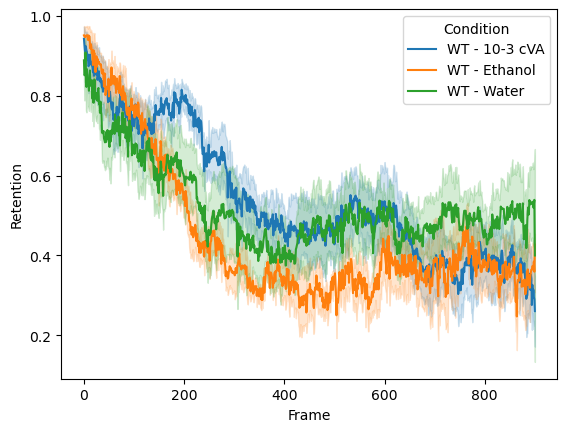

In [164]:
ax = sbs.lineplot(data = retained_df_WT, x = "Frame", y = "Retention", hue="Condition", errorbar="se")
plt.show()